
## Supernova Classification Project

Supernovae are powerful stellar explosions that provide critical insights into astrophysics and cosmology.  
Type Ia supernovae, in particular, act as **standard candles**, allowing us to measure cosmic distances and study the expansion of the Universe.  


## Overview

**Notebook Author:** `Topollo Naketsana` <br>

**Github Repo:** [project](https://github.com/topollonaketsana/Data--Analysis/blob/main/Supernovae_Classification/notebook/svm.ipynb)

#### Python packages used in this project

* pandas
* seaborn
* matplotlib
* astropy
* numpy
* scipy 


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, make_scorer, f1_score
import sncosmo
from astropy.table import Table

### 1. Feature Extraction

In this stage, the goal is to extract meaningful features from the raw supernova light-curve data.  
Each light curve (a set of flux measurements over time and filter) is modeled using the **SALT2** model, which describes the brightness evolution of Type Ia supernovae.

By fitting this model to the observed data, we obtain a compact set of parameters:

- **z** — redshift of the supernova  
- **t₀** — time of peak brightness  
- **x₀** — amplitude (related to overall brightness)  
- **x₁** — stretch parameter (describes how broad or narrow the light curve is)  
- **c** — color parameter (captures color and extinction effects)

These parameters serve as **features** that summarize the essential behavior of each supernova.  
They transform complex, irregular time-series data into a standardized numerical representation suitable for further analysis — such as classification, regression, or cosmological studies.

This stage performs **feature extraction through model fitting**, reducing high-dimensional observational data into a low-dimensional, physically interpretable form.

In [3]:
# 1. Define the fitting function

def fit_supernova(lc):
    
    """
    Small function to fit a light curve with the SALT2 model, using sncosmo and iminuit.
    
    Parameters
    -----------
    lc : astropy.table.Table
        Light curve (in the format sncosmo expects)
    
    Returns
    ----------
    z, t0, x0, x1, c
        Best-fitting parameters of the model
    """

    bnds = {'z':(0.01, 1.5), 't0':(-100,100),
            'x0':(-1e-3, 1e-3), 'x1':(-3, 3), 'c':(-0.5, 0.5)}
    mod = sncosmo.Model('salt2-extended')
    res = sncosmo.fit_lc(lc, mod, vparam_names=mod.param_names,
                         bounds=bnds, minsnr=0)
    return res[0].parameters


In [4]:
# 2. Loop through light curves and extract features
'''import glob

# Saving extracted data
lightcurve_files = glob.glob("../data/supernovae_data/supernovae_data/*.dat")
results = []

for i, file in enumerate(lightcurve_files):
    lc = Table.read(file, format='ascii')

    try:
        params = fit_supernova(lc)
        results.append({
                'id': i,
                'z': params[0],
                't0': params[1],
                'x0': params[2],
                'x1': params[3],
                'c': params[4]
    })

    except Exception as e:
        print(f"Skipping {file}: {e}")

    continue


# Convert results to DataFrame
data = pd.DataFrame(results)

# Save as CSV
data.to_csv('../data/extracted_features.csv.csv', index= False)
print('Feature extraction completed and saved to extracted_features.csv.csv')'''

'import glob\n\n# Saving extracted data\nlightcurve_files = glob.glob("../data/supernovae_data/supernovae_data/*.dat")\nresults = []\n\nfor i, file in enumerate(lightcurve_files):\n    lc = Table.read(file, format=\'ascii\')\n\n    try:\n        params = fit_supernova(lc)\n        results.append({\n                \'id\': i,\n                \'z\': params[0],\n                \'t0\': params[1],\n                \'x0\': params[2],\n                \'x1\': params[3],\n                \'c\': params[4]\n    })\n\n    except Exception as e:\n        print(f"Skipping {file}: {e}")\n\n    continue\n\n\n# Convert results to DataFrame\ndata = pd.DataFrame(results)\n\n# Save as CSV\ndata.to_csv(\'../data/extracted_features.csv.csv\', index= False)\nprint(\'Feature extraction completed and saved to extracted_features.csv.csv\')'

#### 2. Loading and upacking the data

In [5]:
# open the extracted data file
df = pd.read_csv('../data/extracted_features.csv', sep= ',')

# open the data - first 5 entries
df.head()

,id,z,t0,x0,x1,c
0,0,0.664885,64.334480,0.000003,2.734004,-0.218864
1,1,0.732481,-3.667963,0.000003,0.637645,-0.016488
2,2,1.054637,-60.927470,0.000018,0.014775,-0.397927
3,3,1.160663,-63.861990,0.000011,-3.000000,-0.036135
4,4,0.211863,58.629560,0.000012,3.000000,0.127932


### 3. Preprocessing


Before training the model, we can first study the dataset by checking the `info`, `describe`, etc. We also check if the dataset contains any missing values

In [6]:
# dimensions
df.shape

(2000, 6)

In [7]:
# infomation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2000 non-null   int64  
 1   z       2000 non-null   float64
 2   t0      2000 non-null   float64
 3   x0      2000 non-null   float64
 4   x1      2000 non-null   float64
 5   c       2000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 93.9 KB


In [8]:
df.describe()

,id,z,t0,x0,x1,c
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,0.645863,21.797297,0.000009,0.565144,-0.018130
std,577.494589,0.265181,58.386963,0.000041,2.110899,0.283636
min,0.000000,0.010000,-100.000000,-0.001000,-3.000000,-0.500000
25%,499.750000,0.481954,-16.693307,0.000002,-1.017718,-0.226682
50%,999.500000,0.663346,50.679465,0.000004,0.290362,-0.041522
75%,1499.250000,0.784232,63.295040,0.000008,2.999995,0.177621
max,1999.000000,1.500000,100.000000,0.000943,3.000000,0.500000


In [9]:
# since data is all numerical, we can check the mean fro nan
df.isna().mean()

id    0.0
z     0.0
t0    0.0
x0    0.0
x1    0.0
c     0.0
dtype: float64

#### Data contains no missing values and it is in numerical type `dtype` - `float64`

### 4. Visualization 

#### 4.1 Pre - fitting exploration

We study the data before it was extracted - to expore the brightness variation (Light curve)

In [10]:
import os

data_root = '../data/supernovae_data/supernovae_data'
lc_file = os.path.join(data_root, '34.dat')
lc = Table.read(lc_file, format='ascii')

In [11]:
# from table to csv
lc_df = lc.to_pandas()

lc_df.head()

,mjd,filter,flux,flux_error,zp,zpsys
0,0.000,desg,95.18,5.147,27.5,ab
1,0.008,desr,116.10,3.062,27.5,ab
2,0.024,desi,102.80,3.700,27.5,ab
3,0.047,desz,103.70,3.153,27.5,ab
4,2.997,desg,174.70,4.272,27.5,ab


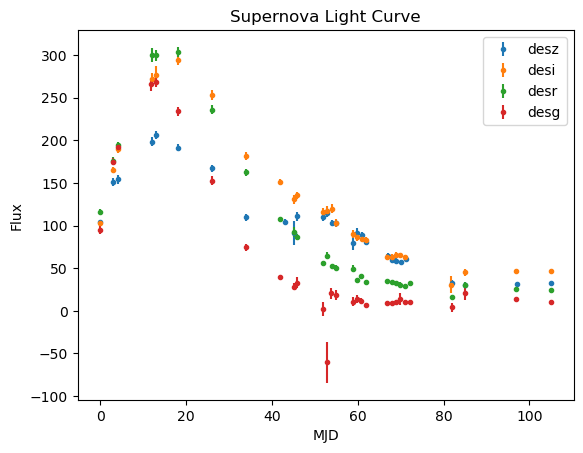

In [12]:
# plot - flux varying with time (Light curve)
for band in set(lc_df['filter']):
    band_data = lc_df[lc_df['filter'] == band]
    plt.errorbar(band_data['mjd'], band_data['flux'],
                 yerr= band_data['flux_error'], fmt='.', label= band)

plt.xlabel('MJD')
plt.ylabel('Flux')
plt.title('Supernova Light Curve')
plt.legend()

plt.show()

#### 4.2 Post-Fitting exploration

c:\Users\topol\anaconda3\Lib\site-packages\sncosmo\fitting.py:191: RuntimeWarning: Dropping following bands from data: desg(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +


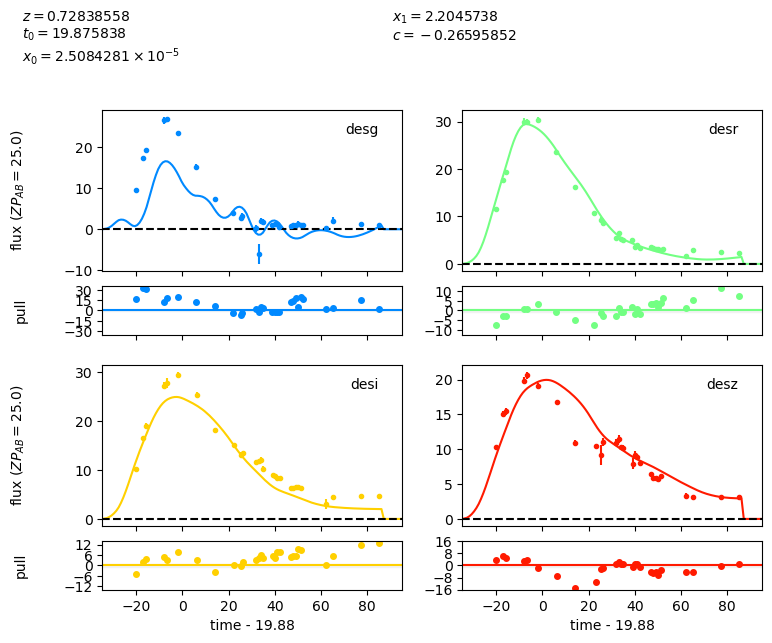

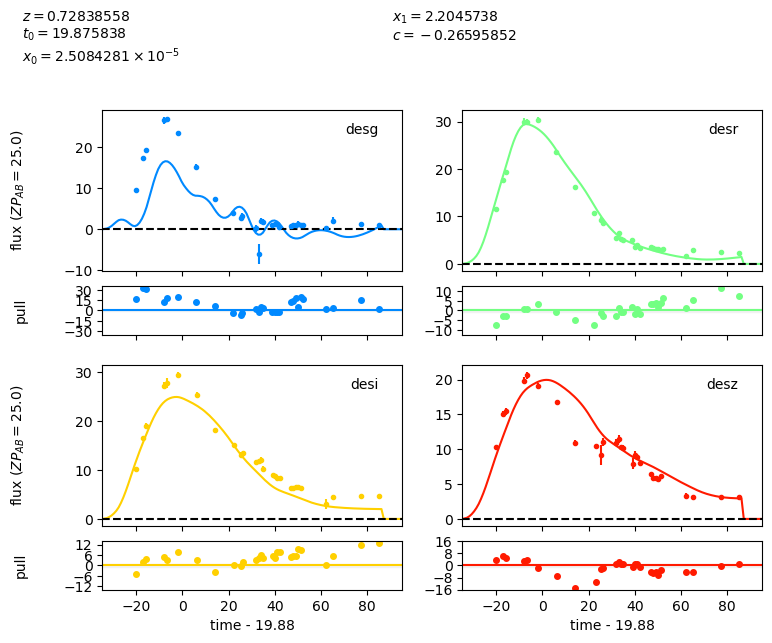

In [13]:
# model and fitting
prms = fit_supernova(lc)
mod = sncosmo.Model('salt2-extended')
mod.parameters = prms

# light curve with sncosmo
sncosmo.plot_lc(lc, mod)

####

### 5. Split data


To run the ML algorithm - Classification, we need to split the dataset into Train set and Test set.We use the ML scikit-learn packages to split the data called `train_test_split`

In [14]:
# target and features 
target = np.loadtxt('../data/labels.txt')
y = target[:, 1]
X = df

# from scikit learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 42)

#### The labels are structured in as follows:

* `Tyle Ia` 1
* `Type  II` 2
* `Type Ibc` 3

Text(0, 0.5, 'Number of Samples')

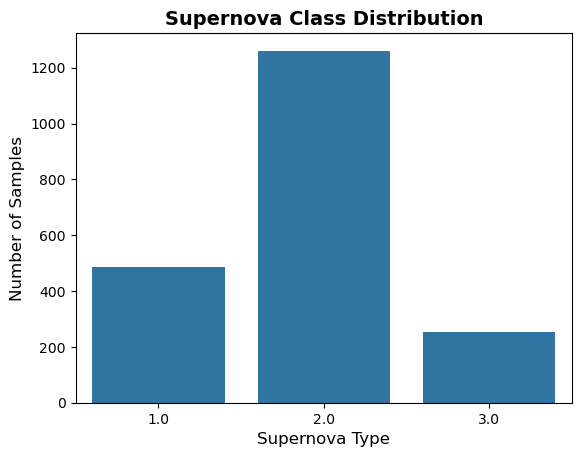

In [28]:
# count plot
import seaborn as sns

sns.countplot(x= y)

# Labels and title
plt.title('Supernova Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Supernova Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

In [16]:
print(f'The shape of X train set {X_train.shape}')
print(f'The shape of the y train set {y_train.shape}')

The shape of X train set (1600, 6)
The shape of the y train set (1600,)


In [17]:
# the count for the labels
print(f'The label consist of: {np.unique(y, return_counts= True)}')

The label consist of: (array([1., 2., 3.]), array([ 485, 1261,  254], dtype=int64))


#### `The classification will then be considered to be multi-classification since the label consist of more than two classes`

### 6. Scale the features

- We have to scale the data because SVM is a distance based algorithm - $w^TX + b$, so scaling (normalizing) makes sure all features contribute equally to the distance computation. 
- Our data has a wide variations of values across samples and features


#### Statistically

#### $z = \frac{x - \mu}{\sigma}$

In [18]:
# scaler
scaler = StandardScaler()

# apply scaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 7. SVC model and training the mode

#### Multi-cleassifier method [documentation](https://scikit-learn.org/stable/modules/svm.html)
The SVM classifier uses one-vs-one (`ovo`) classification strategy - this method splits the classes into a series of binary classifiers

In [19]:
# svc from sklearn
classifier = SVC(decision_function_shape= 'ovo', kernel= 'rbf', class_weight= 'balanced', probability= True)

# training the classifier

###

#### Cross-Validation

In [20]:
# tuning parameters
param_grid = {
    'C': [0.1, 0.56, 1, 10, 128, 152, 201],
    'gamma': ['scale', 0.001, 0.0031, 0.01, 0.1, 0.18, 1, 2.0, 3.0],
    'kernel': ['rbf']
}
scorer = make_scorer(f1_score, average='macro')


grid_search = GridSearchCV(
    classifier, 
    param_grid,
    cv= StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42),
    scoring= scorer,
    n_jobs=-1
)

# Fit the grid search
try:
    grid_search.fit(X_train_scaled, y_train)
    print(f'The model trained successfully') 


except Exception as e:
    print(f'The model failed to train: {e}')

The model trained successfully


In [21]:
# Get best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use best model for predictions
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test_scaled)

Best parameters: {'C': 152, 'gamma': 0.18, 'kernel': 'rbf'}
Best cross-validation score: 0.6170


### 8. Predict the labels

In [22]:
# predict the classes
#y_pred = classifier.predict(X_test_scaled)

####

### 9. Compute the accuracy, precision and recall

To find the perfomance without using the sklearn functions - from the confusion matrix plot

* `Accuracy` = (TP + TN) / (TP + TN +FP + FN)

* `Precision` = TP / (TP + FP) 

* `Recall` = TP / (TP + FN)

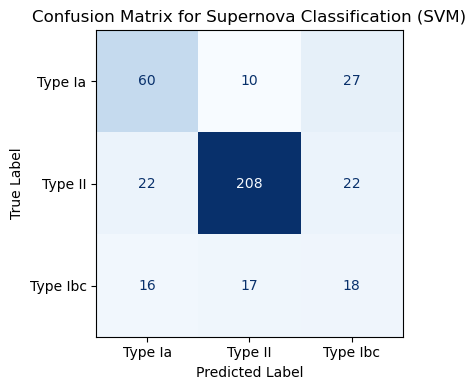

In [23]:
# confusion matrix plot
cm = confusion_matrix(y_test, y_pred)


# class names
class_names = ['Type Ia', 'Type II', 'Type Ibc']

fig, ax = plt.subplots(figsize= (5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= class_names)
disp.plot(cmap= 'Blues', ax= ax, colorbar= False)

# Make labels clearer
plt.title('Confusion Matrix for Supernova Classification (SVM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.show()

In [24]:
# Acurrary - by comparing true and predicted values from cm
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f'Accuracy: {accuracy}')

# Precicion
precision = np.diag(cm) / np.sum(cm, axis=0)
for i, class_name in enumerate(class_names):
    print(f'Precision for {class_name}: {precision[i]:.4f}')


# Recall
recall = np.diag(cm) / np.sum(cm, axis=1)
for i, class_name in enumerate(class_names):
    print(f'Recall for {class_name}: {recall[i]:.4f}')

Accuracy: 0.715
Precision for Type Ia: 0.6122
Precision for Type II: 0.8851
Precision for Type Ibc: 0.2687
Recall for Type Ia: 0.6186
Recall for Type II: 0.8254
Recall for Type Ibc: 0.3529


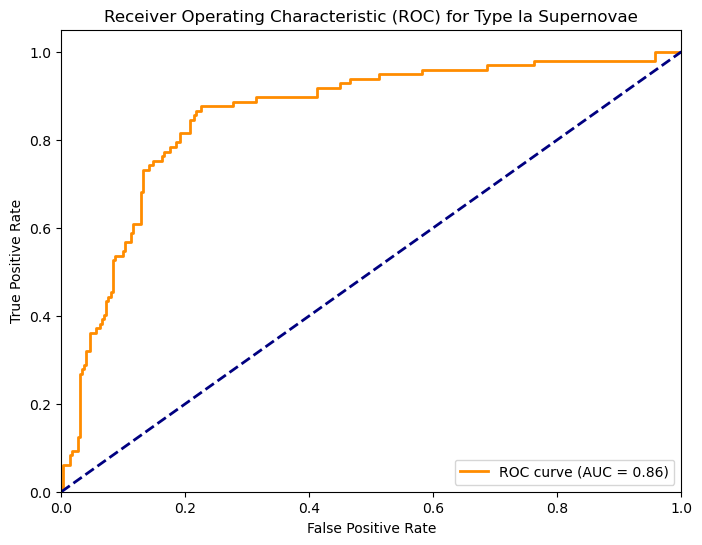

AUC for Type Ia vs. Rest: 0.8560


In [25]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the output for the Type Ia class (class 1)
y_test_binarized = label_binarize(y_test, classes=[1, 2, 3])

# Get the probability scores for the positive class (Type Ia)
y_score = best_classifier.predict_proba(X_test_scaled)

# Compute ROC curve and ROC area for Type Ia
fpr, tpr, _ = roc_curve(y_test_binarized[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

# ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Type Ia Supernovae')
plt.legend(loc="lower right")
plt.show()

print(f"AUC for Type Ia vs. Rest: {roc_auc:.4f}")

### References

- Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). *A Training Algorithm for Optimal Margin Classifiers*. COLT '92. DOI:10.1145/130385.130401. (Theory of SVM)


- scikit-learn developers. *Support Vector Machines — scikit-learn documentation*. https://scikit-learn.org/stable/modules/svm.html 
